In [37]:
!pip install ipykernel
!python -m ipykernel install --user --name andeslink-churn --display-name "Python (andeslink-churn)"

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
Installed kernelspec andeslink-churn in /root/.local/share/jupyter/kernels/andeslink-churn


#CELDA 1 — Imports, constantes y carga del dataset

Observación: Si el archivo churn_sintetico.csv no existe, va a pedir que se suba. Esto es para evitar cualquier inconveniente.

In [38]:
from pathlib import Path
from typing import Final
import shutil
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files

RANDOM_SEED: Final[int] = 42
DATA_PATH: Final[Path] = Path("/content/churn_sintetico.csv")
REPORTS_DIR: Final[Path] = Path("./reports")
REPORTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

sample_data_path: Path = Path("/content/sample_data")
if sample_data_path.exists() and sample_data_path.is_dir():
    shutil.rmtree(sample_data_path)

def load_data() -> pd.DataFrame | None:
    if not DATA_PATH.exists():
        print(f" El archivo '{DATA_PATH.name}' no se encuentra.")
        print("Por favor, subirlo para continuar:")
        uploaded: dict[str, bytes] = files.upload()
        if uploaded:
            uploaded_filename: str = list(uploaded.keys())[0]
            if uploaded_filename != DATA_PATH.name and "churn" in uploaded_filename.lower():
                print(f"Detectado archivo '{uploaded_filename}'. Renombrando a '{DATA_PATH.name}'.")
                os.rename(uploaded_filename, DATA_PATH)
        else:
            print(" error al cargar el archivo.")
            return None

    if DATA_PATH.exists():
        df_loaded: pd.DataFrame = pd.read_csv(DATA_PATH)
        print(f"Dataset cargado correctamente: {df_loaded.shape}")
        return df_loaded
    else:
        print(" No se cargo el archivo. Por favor, ejecuta la celda de nuevo.")
        return None

df: pd.DataFrame | None = load_data()
if df is not None:
    assert "churn" in df.columns, "Columna target 'churn' no encontrada"
    print(f"   Memoria: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Dataset cargado correctamente: (5000, 16)
   Memoria: 1545.7 KB


# CELDA 2 — Chequeo de estructura del dataset: dtypes y nulos



In [39]:
print("=" * 55)
print("TIPOS DE DATOS)")
print("=" * 55)
for col_name, col_type in df.dtypes.items():
    print(f"  {col_name:<30} {col_type}")

print("\n" + "=" * 55)
print("VALORES NULOS POR COLUMNA")
print("=" * 55)
null_counts_series: pd.Series = df.isnull().sum()
null_report: pd.DataFrame = null_counts_series.to_frame(name='nulos')
null_report["porcentaje"] = (null_report["nulos"] / len(df) * 100).round(2)
print(null_report.to_string())

print("\n" + "=" * 55)
print("VALORES UNICOS POR COLUMNA")
print("=" * 55)
for col in df.columns:
    n_unique: int = df[col].nunique()
    sample: list = df[col].unique()[:4].tolist()
    print(f"  {col:<30} {n_unique:>4} unicos  | muestra: {sample}")

TIPOS DE DATOS)
  tenure_months                  int64
  monthly_charge                 float64
  total_charges                  float64
  support_tickets                int64
  late_payments                  int64
  avg_monthly_usage_gb           float64
  contract_type                  object
  payment_method                 object
  internet_service               object
  has_streaming                  int64
  has_security_pack              int64
  num_products                   int64
  region                         object
  customer_age                   int64
  is_promo                       int64
  churn                          int64

VALORES NULOS POR COLUMNA
                      nulos  porcentaje
tenure_months             0         0.0
monthly_charge            0         0.0
total_charges             0         0.0
support_tickets           0         0.0
late_payments             0         0.0
avg_monthly_usage_gb      0         0.0
contract_type             0         0.0
pay

# CELDA 3 — Estadísticas descriptivas

In [40]:
print("NUMERICAS — describe()")
print("=" * 55)

numeric_cols: list[str] = df.select_dtypes(include=np.number).columns.tolist()

pandas_desc: pd.DataFrame = df[numeric_cols].describe().T

pandas_desc['cv'] = (pandas_desc['std'] / pandas_desc['mean']).round(2)
pandas_desc['rango'] = pandas_desc['max'] - pandas_desc['min']

print(pandas_desc[['count', 'mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max']].round(2).to_string())

print("\n\nCATEGORICAS — value_counts()")
print("=" * 55)
cat_cols: list[str] = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n{col}:")
    counts_series: pd.Series = df[col].value_counts().sort_index()
    total_rows: int = len(df)
    percentages_series: pd.Series = (counts_series / total_rows * 100).round(1)

    for index, value in counts_series.items():
        print(f"  {index:<30} {value:>4} ({percentages_series[index]:.1f}%")

NUMERICAS — describe()
                       count     mean      std    cv   min      25%      50%      75%      max
tenure_months         5000.0    36.41    20.84  0.57   1.0    18.00    36.00    55.00    72.00
monthly_charge        5000.0    65.27    17.96  0.28  15.0    53.06    64.96    77.36   127.17
total_charges         5000.0  2371.16  1555.94  0.66  50.0  1100.36  2162.81  3432.66  9083.06
support_tickets       5000.0     1.71     1.30  0.76   0.0     1.00     2.00     2.00     8.00
late_payments         5000.0     0.70     0.84  1.21   0.0     0.00     0.00     1.00     5.00
avg_monthly_usage_gb  5000.0   120.53    49.75  0.41   5.0    86.50   120.03   154.10   324.40
has_streaming         5000.0     0.67     0.47  0.71   0.0     0.00     1.00     1.00     1.00
has_security_pack     5000.0     0.54     0.50  0.92   0.0     0.00     1.00     1.00     1.00
num_products          5000.0     2.52     1.11  0.44   1.0     2.00     3.00     4.00     4.00
customer_age          5000.

# CELDA 4 — Distribución del target (churn)

Distribución del target:
  No churn (0):  3298  (66.0%)
  Churn    (1):  1702  (34.0%)

  Ratio desbalance: 1.94:1


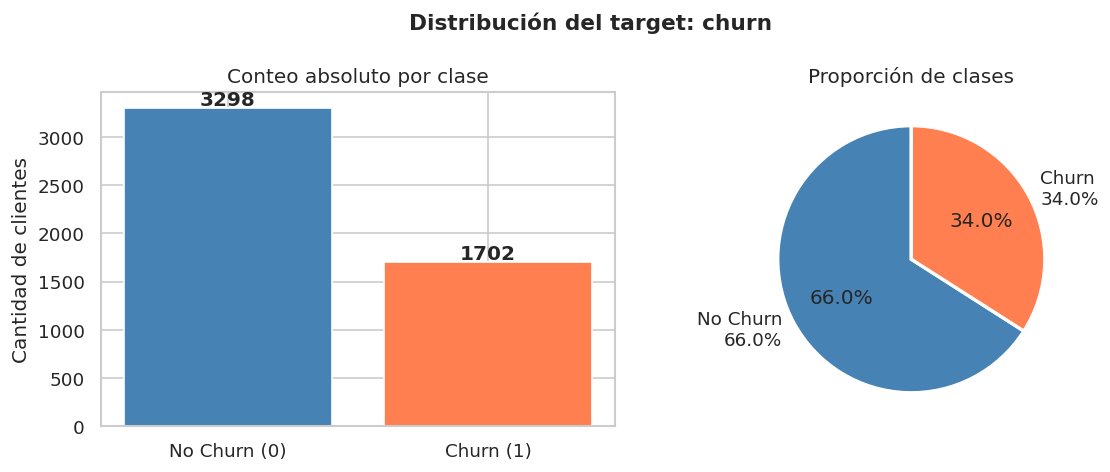


 grafico guardado en reports/eda_01_target_distribution.png


In [41]:
churn_counts = df["churn"].value_counts().sort_index()
churn_pct = (churn_counts / churn_counts.sum() * 100).round(1)

print("Distribución del target:")
print(f"  No churn (0): {churn_counts[0]:>5}  ({churn_pct[0]}%)")
print(f"  Churn    (1): {churn_counts[1]:>5}  ({churn_pct[1]}%)")
print(f"\n  Ratio desbalance: {churn_counts[0]/churn_counts[1]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors: list[str] = ["steelblue", "coral"]
axes[0].bar(["No Churn (0)", "Churn (1)"], churn_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Conteo absoluto por clase")
axes[0].set_ylabel("Cantidad de clientes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(
    churn_counts.values,
    labels=[f"No Churn\n{churn_pct[0]}%", f"Churn\n{churn_pct[1]}%"],
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Proporción de clases")

plt.suptitle("Distribución del target: churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n grafico guardado en reports/eda_01_target_distribution.png")

# CELDA 5 — Distribución de variables numéricas por clase de churn


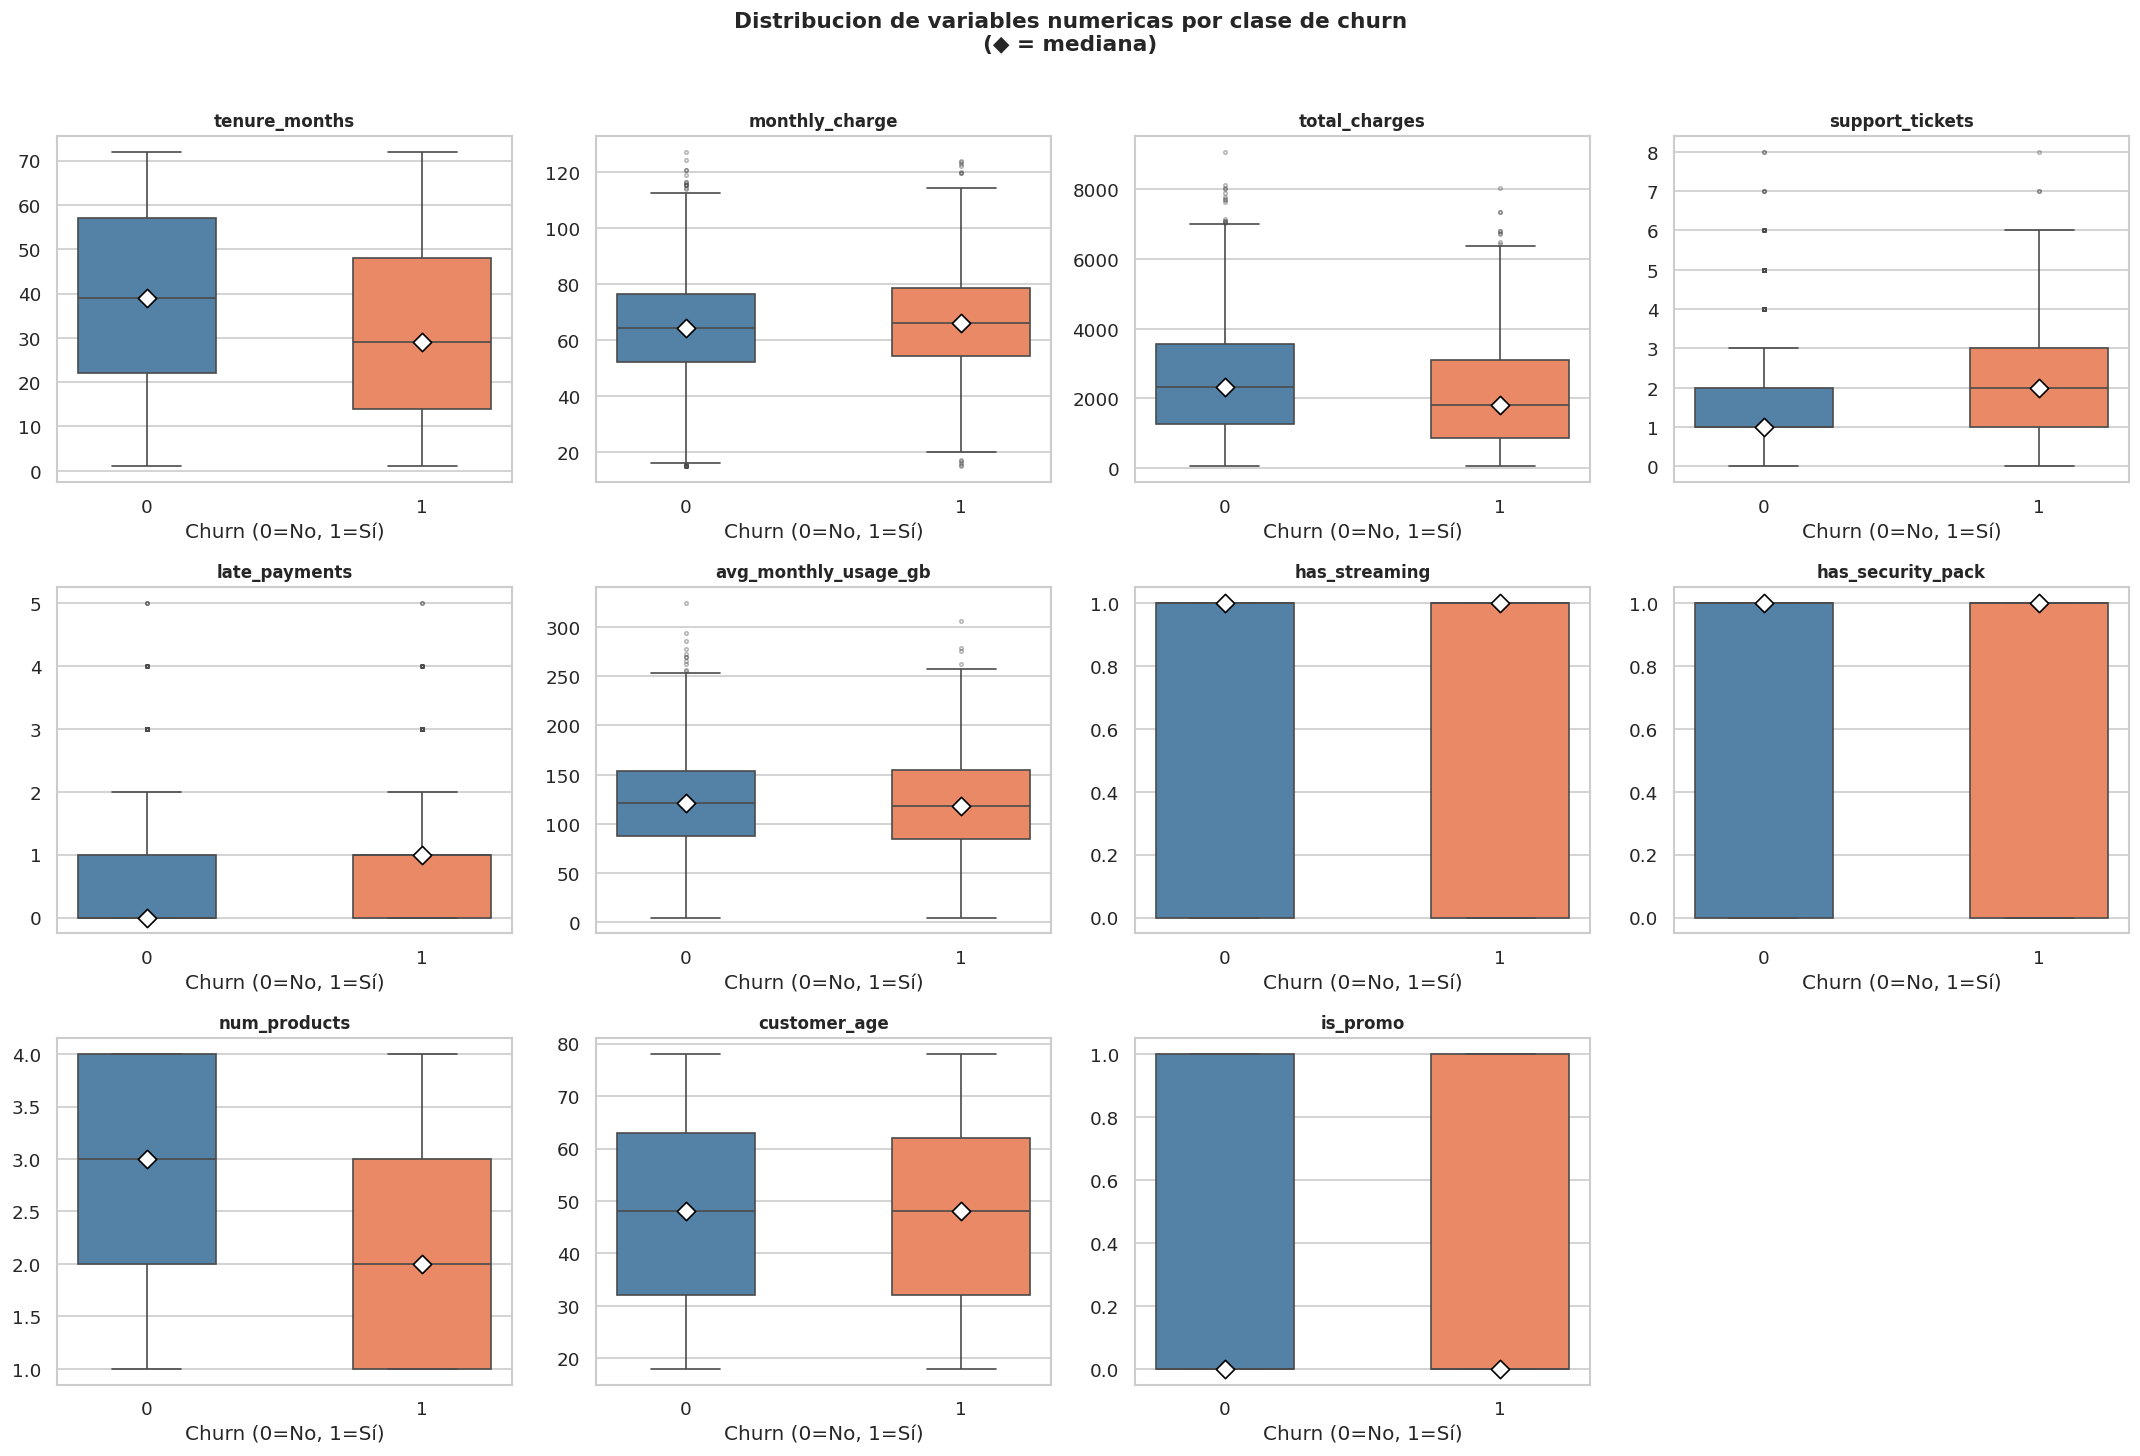

grafico guardado: reports/eda_02_boxplots_by_churn.png


In [42]:
numeric_features: list[str] = [
    "tenure_months", "monthly_charge", "total_charges",
    "support_tickets", "late_payments", "avg_monthly_usage_gb",
    "has_streaming", "has_security_pack", "num_products",
    "customer_age", "is_promo",
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes_flat = axes.flatten()

palette: list[str] = ["steelblue", "coral"]

for i, col in enumerate(numeric_features):
    sns.boxplot(
        data=df,
        x="churn",
        y=col,
        ax=axes_flat[i],
        palette=palette,
        width=0.5,
        flierprops={"marker": "o", "markersize": 2, "alpha": 0.4},
        hue="churn",
        legend=False
    )
    axes_flat[i].set_title(col, fontsize=10, fontweight="bold")
    axes_flat[i].set_xlabel("Churn (0=No, 1=Sí)")
    axes_flat[i].set_ylabel("")

    medians = df.groupby("churn")[col].median().sort_index()

    for churn_val, median_val in medians.items():
        axes_flat[i].scatter(
            churn_val,
            median_val,
            color="white",
            edgecolor="black",
            s=60,
            zorder=5,
            marker="D",
        )

axes_flat[-1].set_visible(False)

plt.suptitle(
    "Distribucion de variables numericas por clase de churn\n(◆ = mediana)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_02_boxplots_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print("grafico guardado: reports/eda_02_boxplots_by_churn.png")

# CELDA 6 — Variables categóricas vs churn (crosstab)


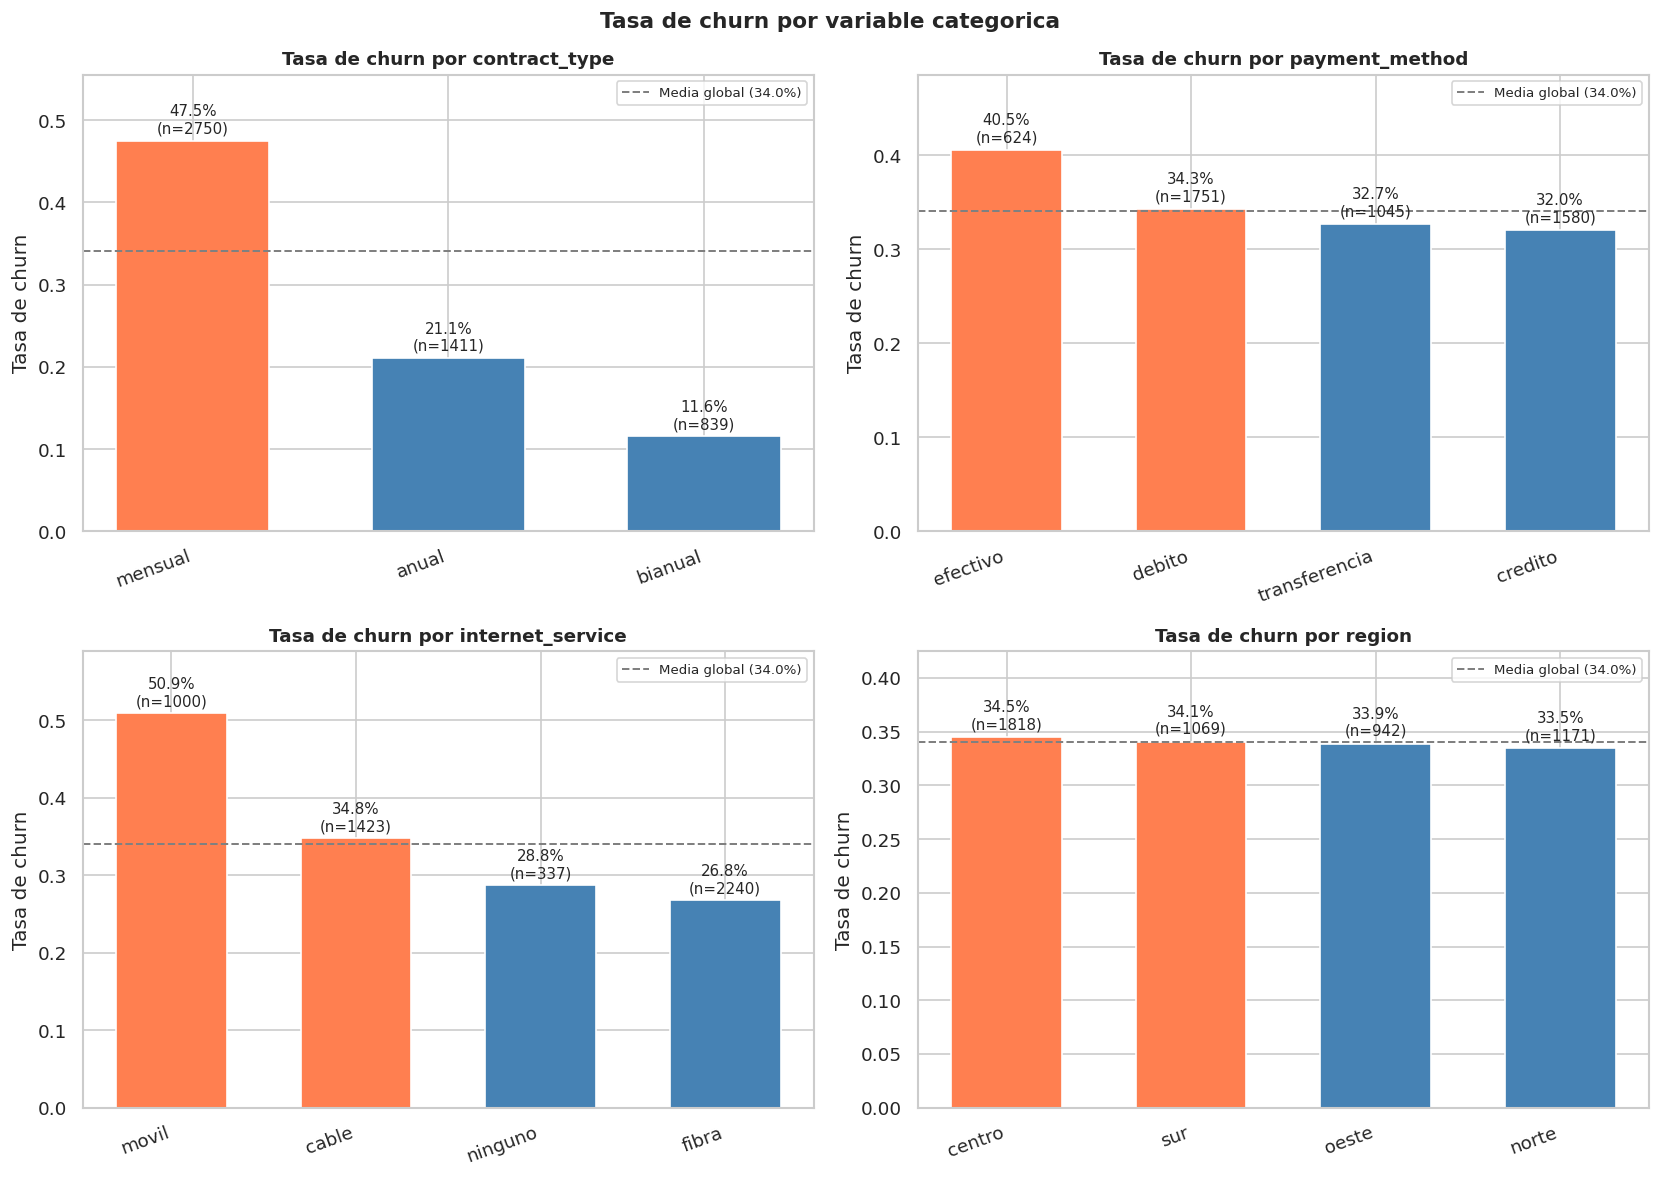

grafico guardado: reports/eda_03_categoricas_vs_churn.png


In [43]:
cat_cols: list[str] = ["contract_type", "payment_method", "internet_service", "region"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)["churn"].mean().sort_values(ascending=False)
    counts = df[col].value_counts()

    bars = axes_flat[i].bar(
        range(len(churn_rate)),
        churn_rate.values,
        color=["coral" if v > df["churn"].mean() else "steelblue" for v in churn_rate.values],
        edgecolor="white",
        width=0.6,
    )

    global_churn_mean = df["churn"].mean()
    axes_flat[i].axhline(
        global_churn_mean,
        color="gray", linestyle="--", linewidth=1.2,
        label=f"Media global ({global_churn_mean:.1%})",
    )

    for j, (cat, rate) in enumerate(churn_rate.items()):
        n = counts[cat]
        axes_flat[i].text(
            j, rate + 0.005,
            f"{rate:.1%}\n(n={n})",
            ha="center", va="bottom", fontsize=9,
        )

    axes_flat[i].set_xticks(range(len(churn_rate)))
    axes_flat[i].set_xticklabels(churn_rate.index, rotation=20, ha="right")
    axes_flat[i].set_title(f"Tasa de churn por {col}", fontsize=11, fontweight="bold")
    axes_flat[i].set_ylabel("Tasa de churn")
    axes_flat[i].set_ylim(0, churn_rate.max() + 0.08)
    axes_flat[i].legend(fontsize=8)

plt.suptitle("Tasa de churn por variable categorica", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_03_categoricas_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print("grafico guardado: reports/eda_03_categoricas_vs_churn.png")

# CELDA 7 — Matriz de correlación entre numéricas

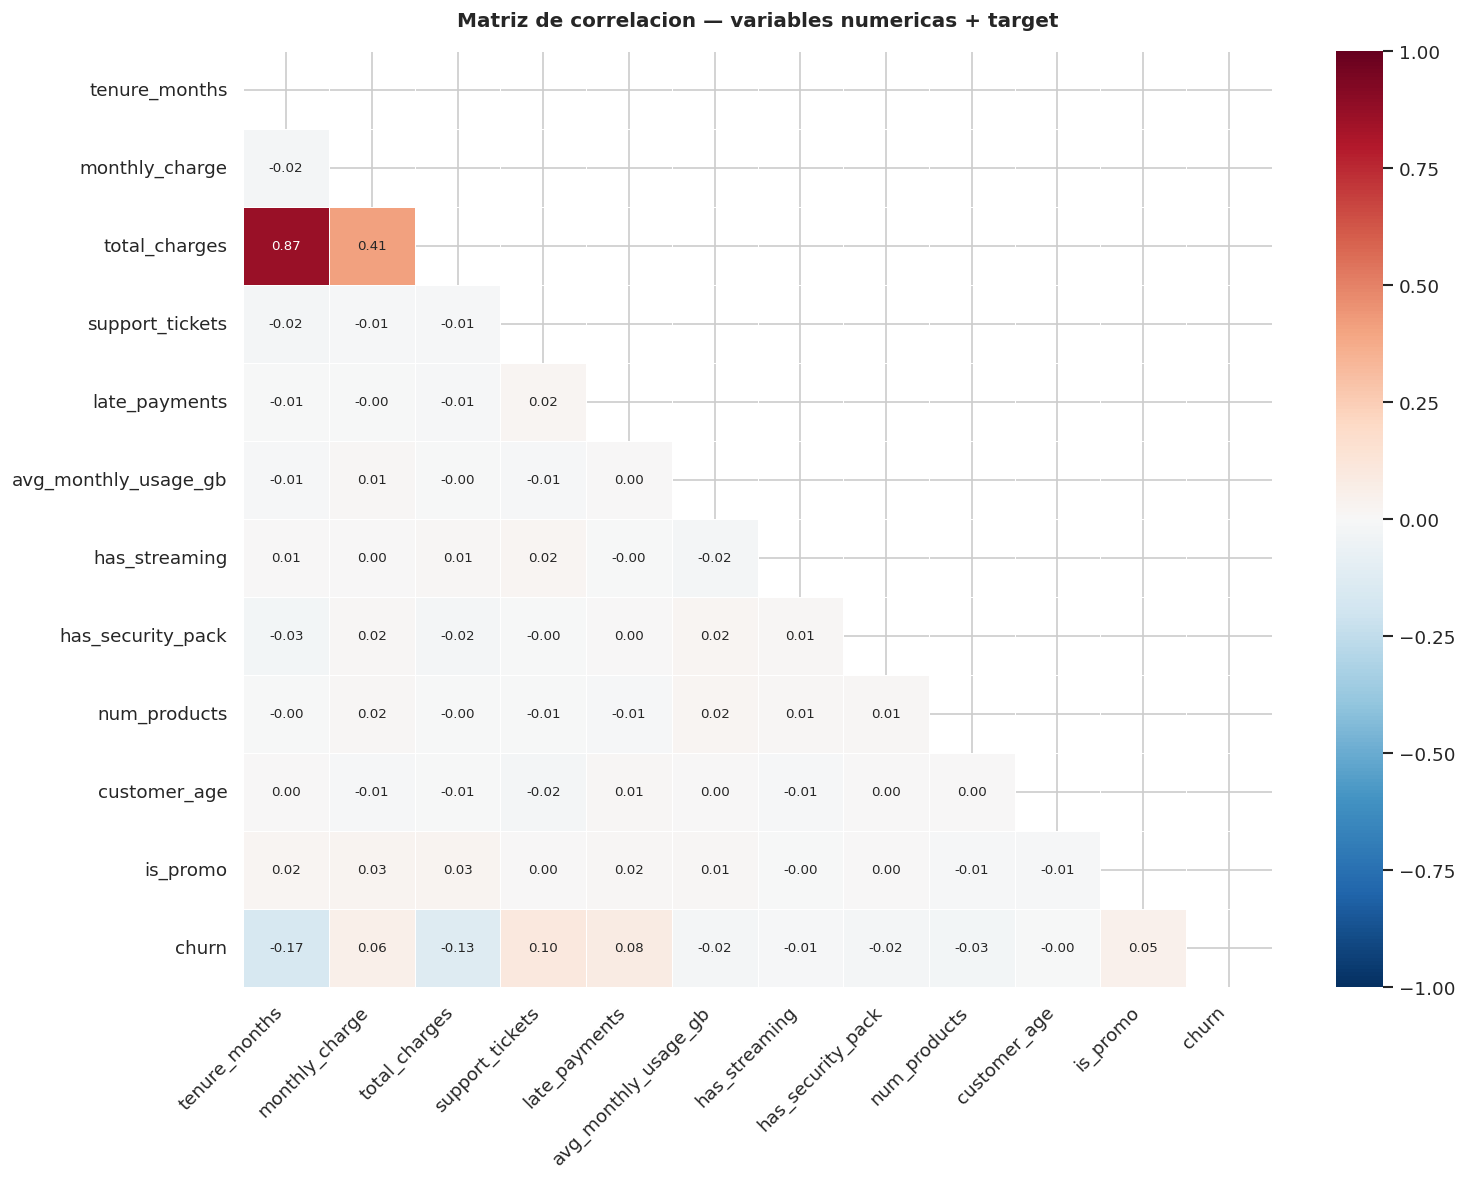

grafico guardado: reports/eda_04_correlacion_heatmap.png

Correlaciones con 'churn' (ordenadas por valor absoluto):
  tenure_months                  -0.1698  ↓ churn
  total_charges                  -0.1253  ↓ churn
  support_tickets                 0.1019  ↑ churn
  late_payments                   0.0809  ↑ churn
  monthly_charge                  0.0619  ↑ churn
  is_promo                        0.0509  ↑ churn
  num_products                   -0.0273  ↓ churn
  has_security_pack              -0.0201  ↓ churn
  avg_monthly_usage_gb           -0.0177  ↓ churn
  has_streaming                  -0.0080  ↓ churn
  customer_age                   -0.0015  ↓ churn


In [44]:
corr_matrix = df[numeric_features + ["churn"]].corr()

mask: np.ndarray = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={"size": 8},
)
ax.set_title(
    "Matriz de correlacion — variables numericas + target",
    fontsize=12, fontweight="bold", pad=15,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_04_correlacion_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("grafico guardado: reports/eda_04_correlacion_heatmap.png")

print("\nCorrelaciones con 'churn' (ordenadas por valor absoluto):")
corr_target: pd.Series = corr_matrix["churn"].drop("churn").sort_values(key=abs, ascending=False)

for feat, val in corr_target.items():
    direction: str = "↑ churn" if val > 0 else "↓ churn"
    print(f"  {feat:<30} {val:>7.4f}  {direction}")

# CELDA 8 — Multicolinealidad: total_charges ≈ tenure × monthly_charge

Ratio: total_charges / (tenure_months × monthly_charge)
        count   mean     std    min     25%  50%     75%     max
ratio  5000.0  1.012  0.2358  0.168  0.9619  1.0  1.0386  5.7722

Mediana del ratio: 1.0000
% filas con ratio entre 0.95 y 1.05: 58.7%


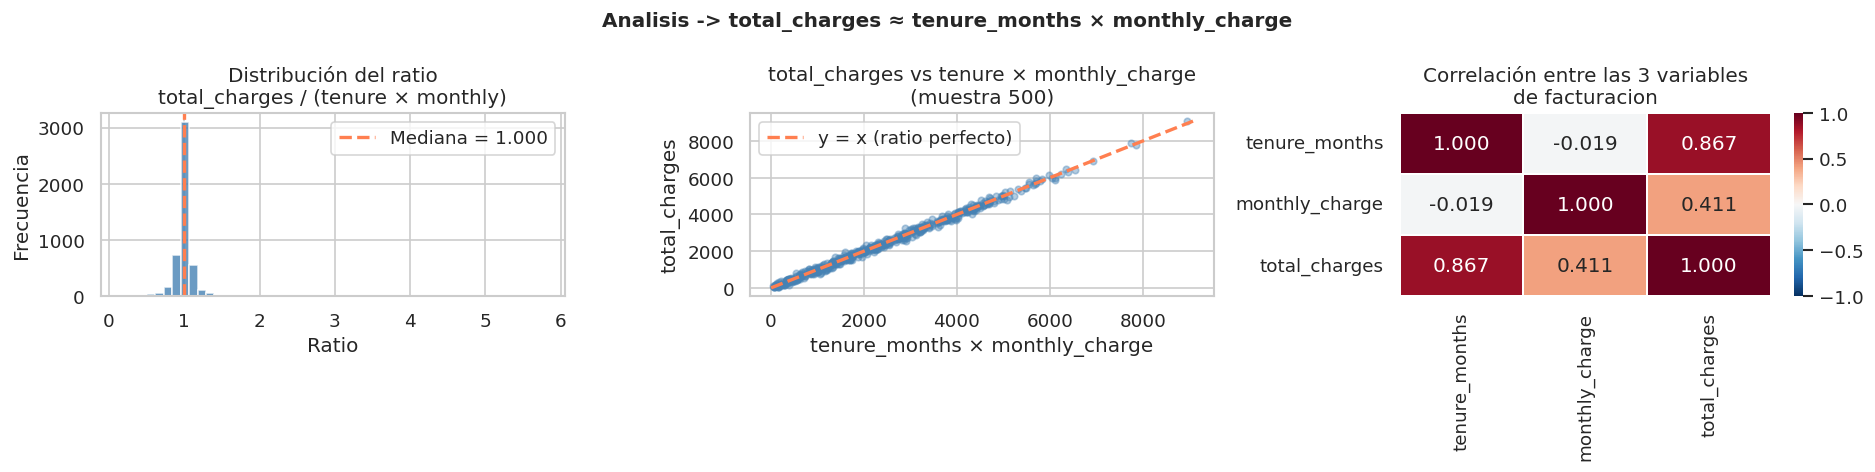

Guardado: reports/eda_05_multicolinealidad.png


In [45]:
df_with_product = df.copy()
df_with_product["product_tenure_monthly"] = df_with_product["tenure_months"] * df_with_product["monthly_charge"]

valid_mask = df_with_product[df_with_product["product_tenure_monthly"] > 0].copy()
valid_mask["ratio"] = valid_mask["total_charges"] / valid_mask["product_tenure_monthly"]
ratio = valid_mask["ratio"]

print("Ratio: total_charges / (tenure_months × monthly_charge)")
print("=" * 55)
print(ratio.describe().to_frame().T.round(4).to_string())
print(f"\nMediana del ratio: {ratio.median():.4f}")
print(f"% filas con ratio entre 0.95 y 1.05: {((ratio > 0.95) & (ratio < 1.05)).mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(ratio, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(ratio.median(), color="coral", linestyle="--", linewidth=2,
                label=f"Mediana = {ratio.median():.3f}")
axes[0].set_title("Distribución del ratio\ntotal_charges / (tenure × monthly)")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

sampled_df = df_with_product.sample(500, random_state=42)

axes[1].scatter(
    sampled_df["product_tenure_monthly"],
    sampled_df["total_charges"],
    alpha=0.4, s=15, color="steelblue",
)
max_val: float = max(sampled_df["product_tenure_monthly"].max(), sampled_df["total_charges"].max())
axes[1].plot([0, max_val], [0, max_val], color="coral", linestyle="--",
             linewidth=2, label="y = x (ratio perfecto)")
axes[1].set_title("total_charges vs tenure × monthly_charge\n(muestra 500)")
axes[1].set_xlabel("tenure_months × monthly_charge")
axes[1].set_ylabel("total_charges")
axes[1].legend()

corr_subset = df[["tenure_months", "monthly_charge", "total_charges"]].corr()
sns.heatmap(
    corr_subset, annot=True, fmt=".3f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    ax=axes[2], linewidths=1,
)
axes[2].set_title("Correlación entre las 3 variables\nde facturacion")

plt.suptitle(
    "Analisis -> total_charges ≈ tenure_months × monthly_charge ",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_05_multicolinealidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: reports/eda_05_multicolinealidad.png")

# CELDA 9 — Correlaciones con el target, visualización final

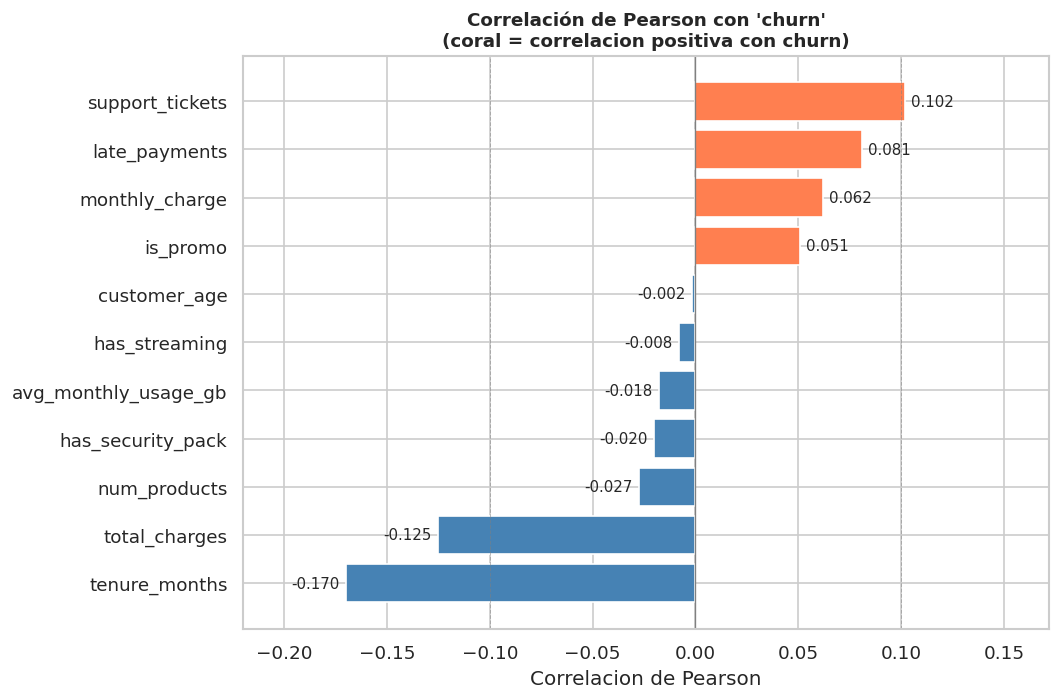

Guardado: reports/eda_06_correlacion_target.png


In [46]:
corr_target: pd.Series = corr_matrix["churn"].drop("churn").sort_values(ascending=True)

colors: list[str] = ["coral" if v > 0 else "steelblue" for v in corr_target.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor="white")

ax.axvline(x=0, color="gray", linestyle="-", linewidth=0.8);
ax.axvline(x=0.1, color="gray", linestyle="--", linewidth=0.6, alpha=0.5);
ax.axvline(x=-0.1, color="gray", linestyle="--", linewidth=0.6, alpha=0.5);

for bar, val in zip(bars, corr_target.values):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    );

ax.set_title(
    "Correlación de Pearson con 'churn'\n(coral = correlacion positiva con churn)",
    fontsize=11, fontweight="bold",
);
ax.set_xlabel("Correlacion de Pearson");
ax.set_xlim(corr_target.min() - 0.05, corr_target.max() + 0.07);
plt.tight_layout();
plt.savefig(REPORTS_DIR / "eda_06_correlacion_target.png", dpi=150, bbox_inches="tight");
plt.show();
print("Guardado: reports/eda_06_correlacion_target.png")

# CONCLUSIONES

El analisis exploratorio muestra que el dataset  no presenta valores nulos, posee variables numéricas y categóricas relevantes para el caso de churn, y el target presenta un desbalance moderado de 66% no churn contra 34% churn. Por este motivo, la evaluación del modelo no debería basarse, en principio, unicamente en accuracy, sino incluir métricas como F1-score, recall, precision, ROC-AUC y matriz de confusión.

Las variables numéricas presentan correlaciones individuales débiles con churn, lo que indica que el abandono no está determinado por una única variable aislada. Las señales más relevantes observadas son la menor antigüedad del cliente, mayor cantidad de tickets de soporte, pagos atrasados y mayor cargo mensual.

En variables categóricas, `contract_type` muestra la mayor discriminación: tasa de churn de 47.5% en contratos mensuales vs 11.6% en bianuales (diferencia de ~ 36%). `internet_service` también discrimina fuertemente: servicio móvil con 50.9% de churn vs fibra con 26.8%. En contraste, `region` no aporta señal discriminante (todas las regiones entre 33.5% y 34.5%), aunque se incluirá en el pipeline por si captura interacciones no lineales con otras variables.

Los resultados de este EDA justifican, en mi opinion, la creación de dos features derivadas: `charges_per_month` (gasto real histórico promedio, reemplaza a `total_charges`) y `tickets_per_year` (tickets de soporte anualizados por antigüedad, normaliza la señal de `support_tickets` para clientes con distintos tiempos en la empresa).

Justificación de `charges_per_month`:

En primer lugar, `total_charges` se aproxima algebraicamente al producto `tenure_months × monthly_charge` (correlación 0.87, ratio mediana = 1.000). Su inclusión puede introducier multicolinealidad sin agregar información independiente y relevante. Por eso desde ya se elimina del futuro pipeline y se reemplaza por la feature derivada `charges_per_month = total_charges / tenure_months`, que captura el gasto real promedio mensual. Esta feature nueva puede correlacionar fuertemente con `monthly_charge` dado el comportamiento algebraico del dataset; su utilidad real se va a evaluar por importancia de features post-entrenamiento.

Justificación de `tickets_per_year`:

Por otro lado, se justifica la creación de una segunda feature derivada: `tickets_per_year = support_tickets / (tenure_months / 12)`, que normaliza la señal de soporte por la antigüedad del cliente y permite comparar clientes con distintos tiempos en la empresa en igualdad de condiciones. SE puede hacer con una proteccion para clientes con baja antigüedad (clip en 6 meses mínimo) para evitar inflación artificial de la tasa anualizada en clientes recientes.

*Siguiente etapa: se va a desarrollar una clasificación binaria con: separación estratificada de datos (64/16/20), codificación OHE para las 4 variables categóricas de baja cardinalidad, escalado estándar para numericas, `class_weight='balanced'` por el desbalance moderado, y comparación de tres modelos supervisados con tracking en MLflow. El objetivo es seleccionar un modelo serializable y reproducible apto para ser consumido por una API de inferencia. Ver PLAN.md

In [49]:
markdown_conclusiones = """# CONCLUSIONES

El analisis exploratorio muestra que el dataset  no presenta valores nulos, posee variables numéricas y categóricas relevantes para el caso de churn, y el target presenta un desbalance moderado de 66% no churn contra 34% churn. Por este motivo, la evaluación del modelo no debería basarse, en principio, unicamente en accuracy, sino incluir métricas como F1-score, recall, precision, ROC-AUC y matriz de confusión.

Las variables numéricas presentan correlaciones individuales débiles con churn, lo que indica que el abandono no está determinado por una única variable aislada. Las señales más relevantes observadas son la menor antigüedad del cliente, mayor cantidad de tickets de soporte, pagos atrasados y mayor cargo mensual.

En variables categóricas, `contract_type` muestra la mayor discriminación: tasa de churn de 47.5% en contratos mensuales vs 11.6% en bianuales (diferencia de ~ 36%). `internet_service` también discrimina fuertemente: servicio móvil con 50.9% de churn vs fibra con 26.8%. En contraste, `region` no aporta señal discriminante (todas las regiones entre 33.5% y 34.5%), aunque se incluirá en el pipeline por si captura interacciones no lineales con otras variables.

Los resultados de este EDA justifican, en mi opinion, la creación de dos features derivadas: `charges_per_month` (gasto real histórico promedio, reemplaza a `total_charges`) y `tickets_per_year` (tickets de soporte anualizados por antigüedad, normaliza la señal de `support_tickets` para clientes con distintos tiempos en la empresa).

Justificación de `charges_per_month`:

En primer lugar, `total_charges` se aproxima algebraicamente al producto `tenure_months × monthly_charge` (correlación 0.87, ratio mediana = 1.000). Su inclusión puede introducier multicolinealidad sin agregar información independiente y relevante. Por eso desde ya se elimina del futuro pipeline y se reemplaza por la feature derivada `charges_per_month = total_charges / tenure_months`, que captura el gasto real promedio mensual. Esta feature nueva puede correlacionar fuertemente con `monthly_charge` dado el comportamiento algebraico del dataset; su utilidad real se va a evaluar por importancia de features post-entrenamiento.

Justificación de `tickets_per_year`:

Por otro lado, se justifica la creación de una segunda feature derivada: `tickets_per_year = support_tickets / (tenure_months / 12)`, que normaliza la señal de soporte por la antigüedad del cliente y permite comparar clientes con distintos tiempos en la empresa en igualdad de condiciones. SE puede hacer con una proteccion para clientes con baja antigüedad (clip en 6 meses mínimo) para evitar inflación artificial de la tasa anualizada en clientes recientes.

*Siguiente etapa: se va a desarrollar una clasificación binaria con: separación estratificada de datos (64/16/20), codificación OHE para las 4 variables categóricas de baja cardinalidad, escalado estándar para numericas, `class_weight='balanced'` por el desbalance moderado, y comparación de tres modelos supervisados con tracking en MLflow. El objetivo es seleccionar un modelo serializable y reproducible apto para ser consumido por una API de inferencia. Ver PLAN.md"""

conclusiones_file_path = REPORTS_DIR / "conclusiones_eda.md"

with open(conclusiones_file_path, "w", encoding="utf-8") as f:
    f.write(markdown_conclusiones)

print(f"Archivo guardado exitosamente en: {conclusiones_file_path}")

Archivo guardado exitosamente en: reports/conclusiones_eda.md
